# # Credit Card Fraud Detection using Machine Learning

## Import Required Libraries

In [ ]:



# Biplob Biswash-Jagannath University
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE







## Load Dataset

In [ ]:
df = pd.read_csv("/content/creditcard.csv")  # download from Kaggle
print("✅ Dataset Loaded Successfully")
print(df.head())


✅ Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

  

In [ ]:
print("\n🔹 Dataset Shape:", df.shape)

print("🔹 Class Distribution:")
print(df['Class'].value_counts())


🔹 Dataset Shape: (23858, 31)
🔹 Class Distribution:
Class
0.0    23769
1.0       88
Name: count, dtype: int64


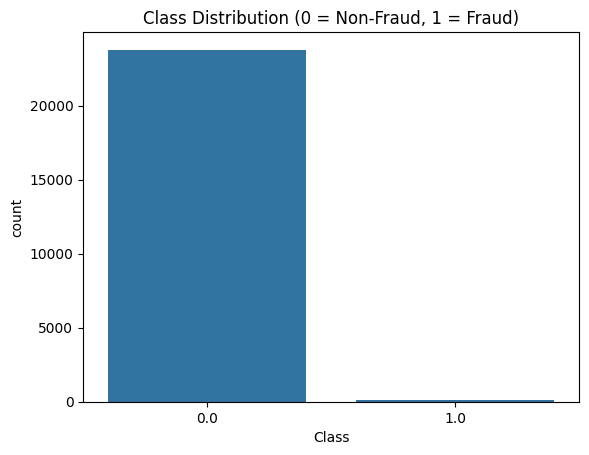

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

## Data preprocessing

*
 Check for Missing Values*

In [ ]:

print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


*Separate Class level*

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']




## Correlation

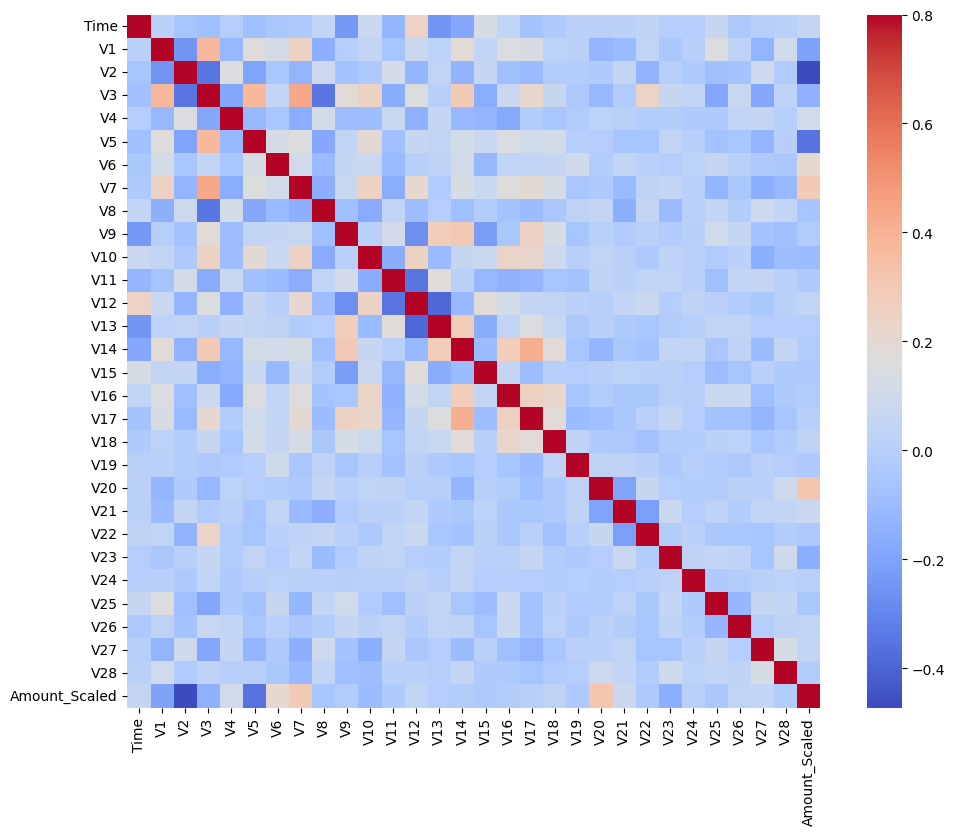

In [ ]:
corrmat = X.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True, cmap="coolwarm")
plt.show()


*Identify and remove rows with Null value in Y (Class column)*

In [ ]:
nan_class_indices = y[y.isna()].index
X = X.drop(nan_class_indices)
y = y.drop(nan_class_indices)

**Scale 'Amount' and optionally 'Time'**

In [ ]:
scaler = StandardScaler()
X['Amount_Scaled'] = scaler.fit_transform(X[['Amount']])
X = X.drop(['Amount'], axis=1)

## Data spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (19085, 30)
Testing size: (4772, 30)


## Handle imbalance data

In [ ]:
sm=SMOTE(random_state=42)
X_train_res,y_train_res=sm.fit_resample(X_train,y_train)
print("After Smote",y_train_res.value_counts())

After Smote Class
0.0    19015
1.0    19015
Name: count, dtype: int64


# Modeling*

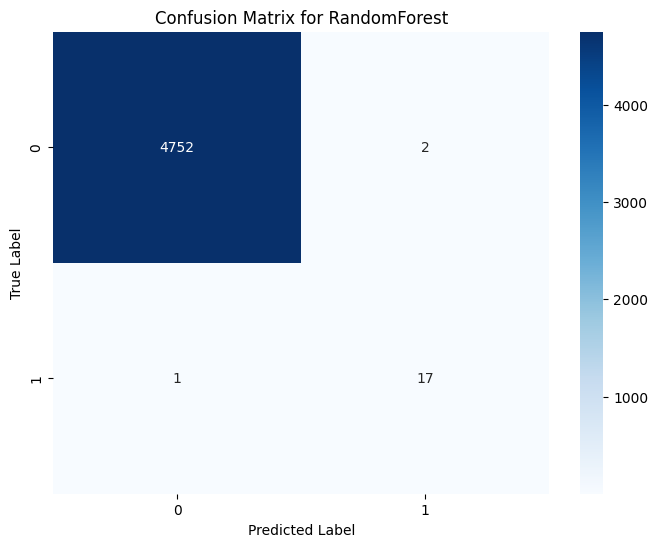

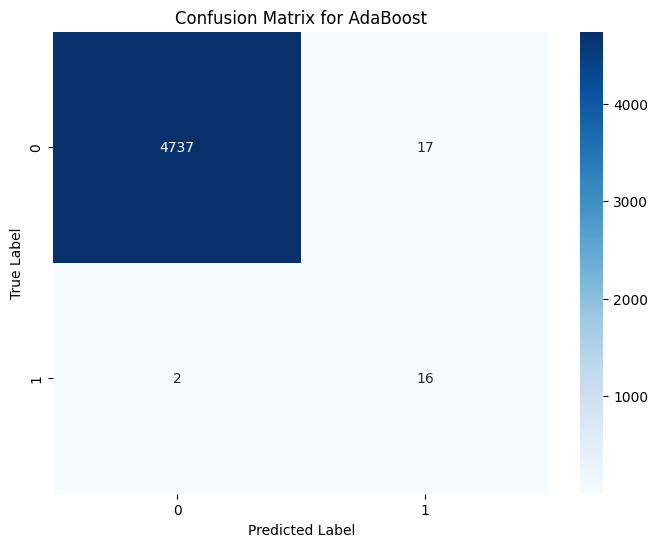

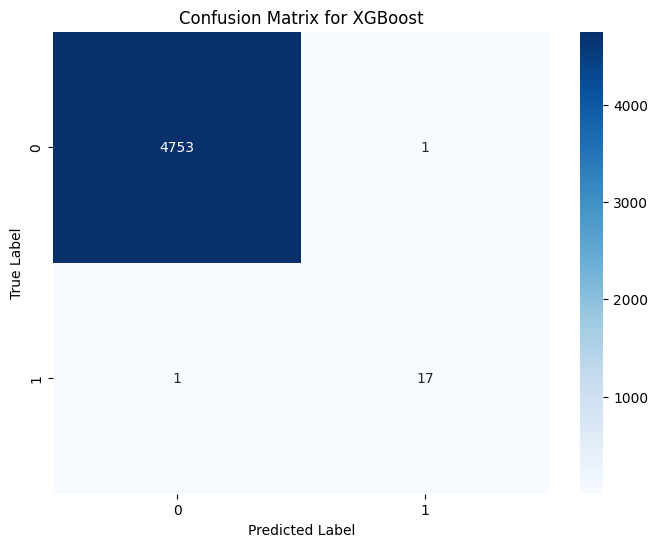

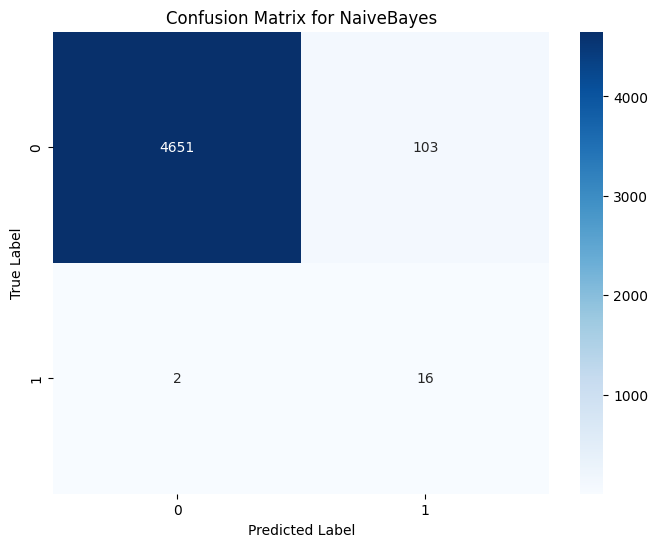

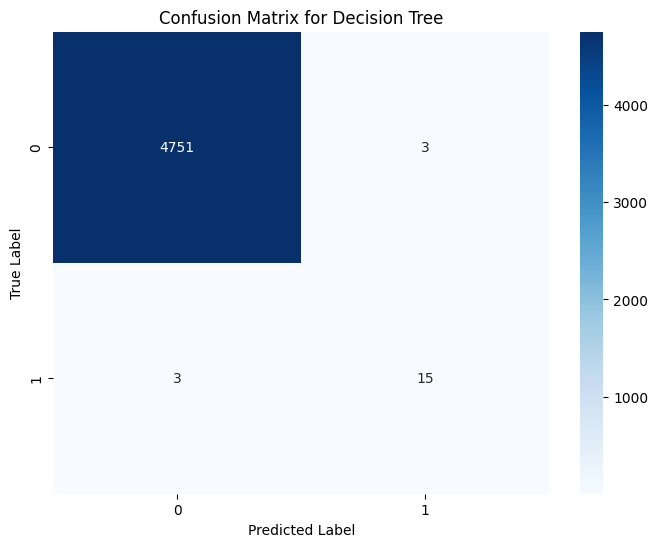

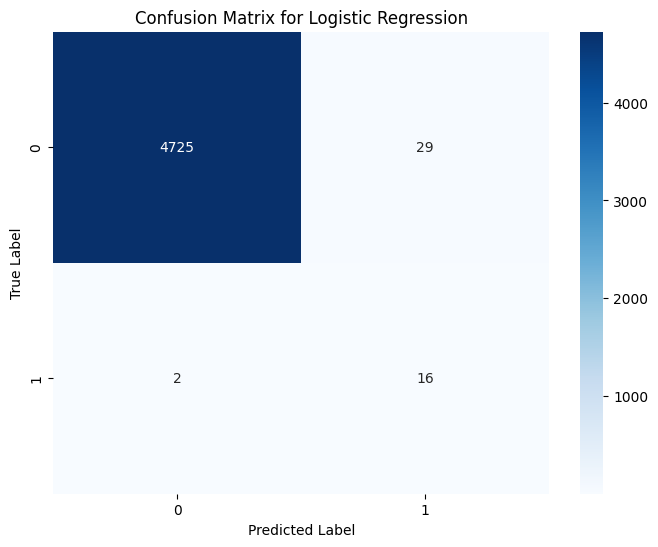

            Classifier  Accuracy  Precision    Recall  F1 Score  \
0         RandomForest  0.999371   0.999393  0.999371  0.999380   
1             AdaBoost  0.996018   0.997636  0.996018  0.996601   
2              XGBoost  0.999581   0.999581  0.999581  0.999581   
3           NaiveBayes  0.977997   0.996307  0.977997  0.985989   
4        Decision Tree  0.998743   0.998743  0.998743  0.998743   
5  Logistic Regression  0.993504   0.997148  0.993504  0.994887   

   Training Time  Testing Time  
0      16.644573      0.041476  
1      11.031968      0.027439  
2       2.065575      0.014901  
3       0.028055      0.003881  
4       1.404657      0.001868  
5      44.537477      0.004136  


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

# Assuming X_train, Y_train, X_test, Y_test are already defined

# Define classifiers
classifiers = {
    "RandomForest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "NaiveBayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=10000)
}

# Prepare table to store results
results = []

# Loop through classifiers and compute metrics
for name, clf in classifiers.items():
    # Train the model and record training time
    start_train = time.time()
    clf.fit(X_train_res, y_train_res)
    end_train = time.time()

    # Predict and record testing time
    start_test = time.time()
    y_pred = clf.predict(X_test)
    end_test = time.time()

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    training_time = end_train - start_train
    testing_time = end_test - start_test


    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Append the results to the list
    results.append({
        "Classifier": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": training_time,
        "Testing Time": testing_time,
        "Confusion Matrix": conf_matrix
    })

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results).drop(columns=['Confusion Matrix'])  # optionally remove matrix from table view
print(results_df)

In [ ]:
results_df

,Classifier,Accuracy,Precision,Recall,F1 Score,Training Time,Testing Time
0,RandomForest,0.999371,0.999393,0.999371,0.999380,16.644573,0.041476
1,AdaBoost,0.996018,0.997636,0.996018,0.996601,11.031968,0.027439
2,XGBoost,0.999581,0.999581,0.999581,0.999581,2.065575,0.014901
3,NaiveBayes,0.977997,0.996307,0.977997,0.985989,0.028055,0.003881
4,Decision Tree,0.998743,0.998743,0.998743,0.998743,1.404657,0.001868
5,Logistic Regression,0.993504,0.997148,0.993504,0.994887,44.537477,0.004136
